# FIFA World Cup 2026 — Exploratory Data Analysis
## Notebook 01: Data Inspection & Results Analysis

**Goal:** Initial inspection of all downloaded datasets, univariate,
bivariate and temporal analysis of historical international results.

**Datasets covered:**
- `martj42` — International results 1872–2026
- `patateriedata` — All matches with daily updates
- `lchikry` — Pre-calculated match features
- `joshfjelstul` — World Cup relational database
- `cashncarry` — FIFA Rankings historical
- `sarazahran1` — WC2026 Elo baseline
- `areezvisram12` — WC2026 fixture

In [1]:
# Standard library
from pathlib import Path

# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

# Project
import sys
sys.path.insert(0, str(Path("../..").resolve()))
from world_cup_2026.config import (
    RAW_DATA_DIR,
    EXTERNAL_DATA_DIR,
    FIGURES_DIR,
    RANDOM_SEED,
)

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.3f}".format)

# Plot style
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.2)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

# Reproducibility
np.random.seed(RANDOM_SEED)

print(f"RAW_DATA_DIR   : {RAW_DATA_DIR}")
print(f"EXTERNAL_DIR   : {EXTERNAL_DATA_DIR}")
print(f"FIGURES_DIR    : {FIGURES_DIR}")
print("Imports OK ✓")

2026-03-28 15:41:24.370 | INFO     | world_cup_2026.config:<module>:12 - PROJ_ROOT path is: C:\Users\feder\Documents\data_repos\world-cup-2026-predictor


RAW_DATA_DIR   : C:\Users\feder\Documents\data_repos\world-cup-2026-predictor\data\raw
EXTERNAL_DIR   : C:\Users\feder\Documents\data_repos\world-cup-2026-predictor\data\external
FIGURES_DIR    : C:\Users\feder\Documents\data_repos\world-cup-2026-predictor\outputs\figures
Imports OK ✓


## 1. Data Loading
### Initial load and inspection of all datasets

In [2]:
# ---------------------------------------------------------------------------
# Dataset 1 — martj42: International results 1872-2026
# ---------------------------------------------------------------------------
df_results = pd.read_csv(RAW_DATA_DIR / "martj42_results" / "results.csv", parse_dates=["date"])
df_shootouts = pd.read_csv(RAW_DATA_DIR / "martj42_results" / "shootouts.csv", parse_dates=["date"])
df_goalscorers = pd.read_csv(RAW_DATA_DIR / "martj42_results" / "goalscorers.csv", parse_dates=["date"])
df_former_names = pd.read_csv(RAW_DATA_DIR / "martj42_results" / "former_names.csv")

# ---------------------------------------------------------------------------
# Dataset 2 — patateriedata: All matches with daily updates
# ---------------------------------------------------------------------------
df_all_matches = pd.read_csv(RAW_DATA_DIR / "patateriedata_results" / "all_matches.csv", parse_dates=["date"])
df_countries = pd.read_csv(RAW_DATA_DIR / "patateriedata_results" / "countries_names.csv")

# ---------------------------------------------------------------------------
# Dataset 3 — lchikry: Pre-calculated features
# ---------------------------------------------------------------------------
df_teams_form = pd.read_csv(RAW_DATA_DIR / "lchikry_features" / "teams_form.csv")
df_match_features = pd.read_csv(RAW_DATA_DIR / "lchikry_features" / "teams_match_features.csv")

# ---------------------------------------------------------------------------
# Dataset 4 — joshfjelstul: World Cup relational database
# ---------------------------------------------------------------------------
df_wc_matches = pd.read_csv(RAW_DATA_DIR / "joshfjelstul_worldcup" / "matches.csv")
df_wc_groups = pd.read_csv(RAW_DATA_DIR / "joshfjelstul_worldcup" / "groups.csv")
df_wc_goals = pd.read_csv(RAW_DATA_DIR / "joshfjelstul_worldcup" / "goals.csv")
df_wc_penalties = pd.read_csv(RAW_DATA_DIR / "joshfjelstul_worldcup" / "penalty_kicks.csv")
df_wc_squads = pd.read_csv(RAW_DATA_DIR / "joshfjelstul_worldcup" / "squads.csv")

# ---------------------------------------------------------------------------
# Dataset 5 — cashncarry: FIFA Rankings
# ---------------------------------------------------------------------------
df_rankings = pd.read_csv(RAW_DATA_DIR / "cashncarry_rankings" / "fifa_ranking-2024-06-20.csv", parse_dates=["rank_date"])

# ---------------------------------------------------------------------------
# Dataset 6 — sarazahran1: WC2026 Elo baseline
# ---------------------------------------------------------------------------
df_elo_baseline = pd.read_csv(RAW_DATA_DIR / "sarazahran1_baseline" / "future_match_probabilities_baseline.csv")

# ---------------------------------------------------------------------------
# Dataset 7 — areezvisram12: WC2026 fixture
# ---------------------------------------------------------------------------
df_fixture = pd.read_csv(RAW_DATA_DIR / "areezvisram12_fixture" / "matches.csv")
df_teams_2026 = pd.read_csv(RAW_DATA_DIR / "areezvisram12_fixture" / "teams.csv")
df_stages = pd.read_csv(RAW_DATA_DIR / "areezvisram12_fixture" / "tournament_stages.csv")

print("All datasets loaded ✓")
print(f"\n{'Dataset':<25} {'Shape':>12}")
print("-" * 40)
for name, df in [
    ("df_results",        df_results),
    ("df_shootouts",      df_shootouts),
    ("df_goalscorers",    df_goalscorers),
    ("df_all_matches",    df_all_matches),
    ("df_teams_form",     df_teams_form),
    ("df_match_features", df_match_features),
    ("df_wc_matches",     df_wc_matches),
    ("df_rankings",       df_rankings),
    ("df_elo_baseline",   df_elo_baseline),
    ("df_fixture",        df_fixture),
    ("df_teams_2026",     df_teams_2026),
]:
    print(f"{name:<25} {str(df.shape):>12}")

All datasets loaded ✓

Dataset                          Shape
----------------------------------------
df_results                  (49071, 9)
df_shootouts                  (665, 5)
df_goalscorers              (47555, 8)
df_all_matches              (51384, 8)
df_teams_form              (102094, 5)
df_match_features          (43364, 35)
df_wc_matches                (900, 37)
df_rankings                 (67472, 8)
df_elo_baseline               (72, 13)
df_fixture                    (104, 8)
df_teams_2026                  (48, 5)


### 1.1 Initial inspection by dataset

In [3]:
print("=" * 60)
print("df_results — International Football Results 1872-2026")
print("=" * 60)
print(f"\nShape: {df_results.shape}")
print(f"Date range: {df_results['date'].min().date()} → {df_results['date'].max().date()}")
print(f"\nDtypes:\n{df_results.dtypes}")
print(f"\nNulls:\n{df_results.isnull().sum()}")
print(f"\nDuplicates: {df_results.duplicated().sum()}")
print(f"\nSample:\n{df_results.head(3).to_string()}")
print(f"\nTournament types ({df_results['tournament'].nunique()} unique):")
print(df_results['tournament'].value_counts().head(15).to_string())

df_results — International Football Results 1872-2026

Shape: (49071, 9)
Date range: 1872-11-30 → 2026-01-26

Dtypes:
date          datetime64[ns]
home_team             object
away_team             object
home_score             int64
away_score             int64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object

Nulls:
date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

Duplicates: 0

Sample:
        date home_team away_team  home_score  away_score tournament     city   country  neutral
0 1872-11-30  Scotland   England           0           0   Friendly  Glasgow  Scotland    False
1 1873-03-08   England  Scotland           4           2   Friendly   London   England    False
2 1874-03-07  Scotland   England           2           1   Friendly  Glasgow  Scotland    False

Tournament types (191 unique):
to

In [4]:
print("=" * 60)
print("df_fixture — WC2026 Fixture (104 matches)")
print("=" * 60)
print(f"\nColumns: {df_fixture.columns.tolist()}")
print(f"\nNulls:\n{df_fixture.isnull().sum()}")
print(f"\nSample:\n{df_fixture.head(10).to_string()}")

print("\n" + "=" * 60)
print("df_teams_2026 — 48 Qualified Teams")
print("=" * 60)
print(f"\nColumns: {df_teams_2026.columns.tolist()}")
print(f"\n{df_teams_2026.to_string()}")

df_fixture — WC2026 Fixture (104 matches)

Columns: ['id', 'match_number', 'home_team_id', 'away_team_id', 'city_id', 'stage_id', 'kickoff_at', 'match_label']

Nulls:
id               0
match_number     0
home_team_id    32
away_team_id    32
city_id          0
stage_id         0
kickoff_at       0
match_label      0
dtype: int64

Sample:
   id  match_number  home_team_id  away_team_id  city_id  stage_id              kickoff_at match_label
0   1             1         1.000         2.000       15         1  2026-06-11 15:00:00-06     Group A
1   2             2         3.000         4.000       14         1  2026-06-11 22:00:00-06     Group A
2   3             3         5.000         6.000       12         1  2026-06-12 15:00:00-04     Group B
3   4             4        13.000        14.000        6         1  2026-06-12 21:00:00-07     Group D
4   5             5         7.000         8.000       10         1  2026-06-13 15:00:00-07     Group B
5   6             6         9.000        

In [5]:
print("=" * 60)
print("df_elo_baseline — WC2026 Elo Match Probability Baseline")
print("=" * 60)
print(f"\nColumns: {df_elo_baseline.columns.tolist()}")
print(f"\nSample:\n{df_elo_baseline.head(10).to_string()}")
print(f"\nStats:\n{df_elo_baseline.describe().to_string()}")

df_elo_baseline — WC2026 Elo Match Probability Baseline

Columns: ['group', 'home_team', 'away_team', 'date', 'tournament', 'home_elo', 'away_elo', 'elo_diff', 'home_injury_flag', 'away_injury_flag', 'p_home_win', 'p_draw', 'p_away_win']

Sample:
  group     home_team       away_team  date                   tournament  home_elo  away_elo  elo_diff  home_injury_flag  away_injury_flag  p_home_win  p_draw  p_away_win
0     A        Mexico    South Africa   NaN  FIFA World Cup 2026 - Group      1890  1600.000   290.000                 0                 0       0.709   0.158       0.134
1     A        Mexico     South Korea   NaN  FIFA World Cup 2026 - Group      1890  1755.000   135.000                 0                 0       0.547   0.201       0.251
2     A        Mexico  UEFA_Playoff_D   NaN  FIFA World Cup 2026 - Group      1890       NaN       NaN                 0                 0       0.360   0.280       0.360
3     A  South Africa     South Korea   NaN  FIFA World Cup 2026 - Gr

In [6]:
print("=" * 60)
print("df_match_features — Pre-calculated Match Features (35 cols)")
print("=" * 60)
print(f"\nColumns:\n{df_match_features.columns.tolist()}")
print(f"\nNulls (top 10):\n{df_match_features.isnull().sum().sort_values(ascending=False).head(10)}")
print(f"\nDate range: {df_match_features.iloc[:,0].min()} → {df_match_features.iloc[:,0].max()}")
print(f"\nSample:\n{df_match_features.head(3).to_string()}")

df_match_features — Pre-calculated Match Features (35 cols)

Columns:
['home_elo', 'away_elo', 'elo_diff', 'home_avg_overall', 'home_max_overall', 'home_avg_attack', 'home_avg_defense', 'home_avg_pace', 'home_avg_shooting', 'home_avg_passing', 'away_avg_overall', 'away_max_overall', 'away_avg_attack', 'away_avg_defense', 'away_avg_pace', 'away_avg_shooting', 'away_avg_passing', 'overall_diff', 'attack_diff', 'defense_diff', 'home_form_scored', 'home_form_conceded', 'home_form_win_rate', 'away_form_scored', 'away_form_conceded', 'away_form_win_rate', 'is_neutral', 'is_world_cup', 'is_continental', 'home_goals', 'away_goals', '_home_team', '_away_team', '_date', '_tournament']

Nulls (top 10):
away_avg_pace        801
away_avg_passing     801
away_avg_shooting    801
home_avg_pace        697
home_avg_passing     697
home_avg_shooting    697
home_elo               0
elo_diff               0
away_elo               0
home_avg_defense       0
dtype: int64

Date range: 952.1888553525022 → 210

### 1.2 Fixture resolution — join teams to get real names

In [7]:
# Merge paso 1 — home team
df_fixture_named = df_fixture.merge(
    df_teams_2026[["id", "team_name", "fifa_code", "group_letter"]].rename(columns={
        "id": "home_team_id",
        "team_name": "home_team",
        "fifa_code": "home_code",
        "group_letter": "group",
    }),
    on="home_team_id",
    how="left",
)

# Merge paso 2 — away team
df_fixture_named = df_fixture_named.merge(
    df_teams_2026[["id", "team_name", "fifa_code"]].rename(columns={
        "id": "away_team_id",
        "team_name": "away_team",
        "fifa_code": "away_code",
    }),
    on="away_team_id",
    how="left",
)

# Parse kickoff datetime
df_fixture_named["kickoff_at"] = pd.to_datetime(df_fixture_named["kickoff_at"], utc=True)

# Solo fase de grupos (stage_id == 1)
df_group_stage = df_fixture_named[df_fixture_named["stage_id"] == 1].copy()

print(f"Fixture total: {len(df_fixture_named)} matches")
print(f"Group stage:   {len(df_group_stage)} matches")
print(f"\nGroup stage sample:")
print(
    df_group_stage[["match_number", "group", "home_team", "away_team", "kickoff_at"]]
    .head(12)
    .to_string(index=False)
)

print(f"\nStages distribution:")
print(df_fixture_named["stage_id"].value_counts().sort_index().to_string())

Fixture total: 104 matches
Group stage:   72 matches

Group stage sample:
 match_number group             home_team             away_team                kickoff_at
            1     A                Mexico          South Africa 2026-06-11 21:00:00+00:00
            2     A           South Korea Winner UEFA Playoff D 2026-06-12 04:00:00+00:00
            3     B                Canada Winner UEFA Playoff A 2026-06-12 19:00:00+00:00
            4     D                   USA              Paraguay 2026-06-13 04:00:00+00:00
            5     B                 Qatar           Switzerland 2026-06-13 22:00:00+00:00
            6     C                Brazil               Morocco 2026-06-13 22:00:00+00:00
            7     C                 Haiti              Scotland 2026-06-14 01:00:00+00:00
            8     D             Australia Winner UEFA Playoff C 2026-06-14 07:00:00+00:00
            9     E               Germany               Curaçao 2026-06-14 18:00:00+00:00
           10     F       

In [8]:
confirmed = df_teams_2026[df_teams_2026["is_placeholder"] == False]
placeholders = df_teams_2026[df_teams_2026["is_placeholder"] == True]

print(f"Confirmed teams : {len(confirmed)}")
print(f"Placeholders    : {len(placeholders)}")
print(f"\nPlaceholders:")
print(placeholders[["team_name", "fifa_code", "group_letter"]].to_string(index=False))

print(f"\nConfirmed teams by group:")
for group in sorted(confirmed["group_letter"].unique()):
    teams = confirmed[confirmed["group_letter"] == group]["team_name"].tolist()
    print(f"  Group {group}: {', '.join(teams)}")

Confirmed teams : 42
Placeholders    : 6

Placeholders:
            team_name fifa_code group_letter
Winner UEFA Playoff D      UEPD            A
Winner UEFA Playoff A      UEPA            B
Winner UEFA Playoff C      UEPC            D
Winner UEFA Playoff B      UEPB            F
Winner FIFA Playoff 2      FP02            I
Winner FIFA Playoff 1      FP01            K

Confirmed teams by group:
  Group A: Mexico, South Africa, South Korea
  Group B: Canada, Qatar, Switzerland
  Group C: Brazil, Morocco, Haiti, Scotland
  Group D: USA, Paraguay, Australia
  Group E: Germany, Curaçao, Côte d'Ivoire, Ecuador
  Group F: Netherlands, Japan, Tunisia
  Group G: Belgium, Egypt, IR Iran, New Zealand
  Group H: Spain, Cabo Verde, Saudi Arabia, Uruguay
  Group I: France, Senegal, Norway
  Group J: Argentina, Algeria, Austria, Jordan
  Group K: Portugal, Uzbekistan, Colombia
  Group L: England, Croatia, Ghana, Panama


## 2. Univariate Analysis
### 2.1 Goals distribution — Historical international matches

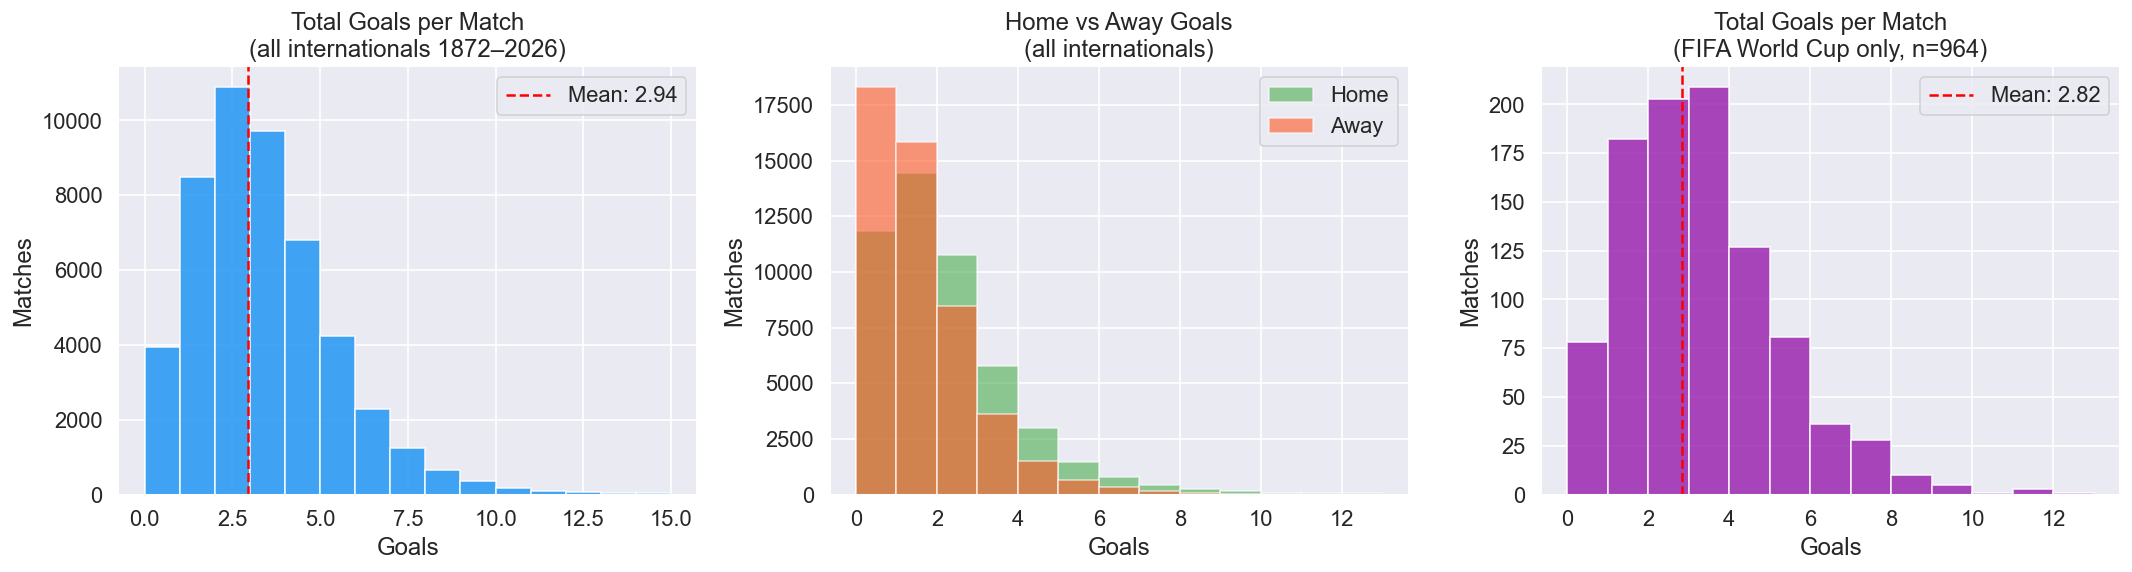


All internationals — mean goals/match : 2.938
World Cup only  — mean goals/match    : 2.822

Result distribution (all):
result
Home Win   49.000
Away Win   28.270
Draw       22.730

Result distribution (World Cup):
result
Home Win   45.540
Away Win   32.260
Draw       22.200


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Total goals per match ---
df_results["total_goals"] = df_results["home_score"] + df_results["away_score"]

axes[0].hist(
    df_results["total_goals"],
    bins=range(0, 16),
    edgecolor="white",
    color="#2196F3",
    alpha=0.85,
)
axes[0].set_title("Total Goals per Match\n(all internationals 1872–2026)")
axes[0].set_xlabel("Goals")
axes[0].set_ylabel("Matches")
axes[0].axvline(df_results["total_goals"].mean(), color="red", linestyle="--", label=f"Mean: {df_results['total_goals'].mean():.2f}")
axes[0].legend()

# --- Home vs Away goals ---
axes[1].hist(df_results["home_score"], bins=range(0, 14), alpha=0.6, label="Home", color="#4CAF50", edgecolor="white")
axes[1].hist(df_results["away_score"], bins=range(0, 14), alpha=0.6, label="Away", color="#FF5722", edgecolor="white")
axes[1].set_title("Home vs Away Goals\n(all internationals)")
axes[1].set_xlabel("Goals")
axes[1].set_ylabel("Matches")
axes[1].legend()

# --- World Cup only ---
df_wc_only = df_results[df_results["tournament"] == "FIFA World Cup"]
axes[2].hist(
    df_wc_only["total_goals"],
    bins=range(0, 14),
    edgecolor="white",
    color="#9C27B0",
    alpha=0.85,
)
axes[2].set_title(f"Total Goals per Match\n(FIFA World Cup only, n={len(df_wc_only):,})")
axes[2].set_xlabel("Goals")
axes[2].set_ylabel("Matches")
axes[2].axvline(df_wc_only["total_goals"].mean(), color="red", linestyle="--", label=f"Mean: {df_wc_only['total_goals'].mean():.2f}")
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_goals_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nAll internationals — mean goals/match : {df_results['total_goals'].mean():.3f}")
print(f"World Cup only  — mean goals/match    : {df_wc_only['total_goals'].mean():.3f}")
print(f"\nResult distribution (all):")
df_results["result"] = df_results.apply(
    lambda r: "Home Win" if r.home_score > r.away_score
    else ("Away Win" if r.home_score < r.away_score else "Draw"),
    axis=1
)
print(df_results["result"].value_counts(normalize=True).mul(100).round(2).to_string())
print(f"\nResult distribution (World Cup):")
df_wc_only = df_results[df_results["tournament"] == "FIFA World Cup"].copy()
df_wc_only["result"] = df_wc_only.apply(
    lambda r: "Home Win" if r.home_score > r.away_score
    else ("Away Win" if r.home_score < r.away_score else "Draw"),
    axis=1
)
print(df_wc_only["result"].value_counts(normalize=True).mul(100).round(2).to_string())

### 2.2 Match results distribution — Home advantage analysis

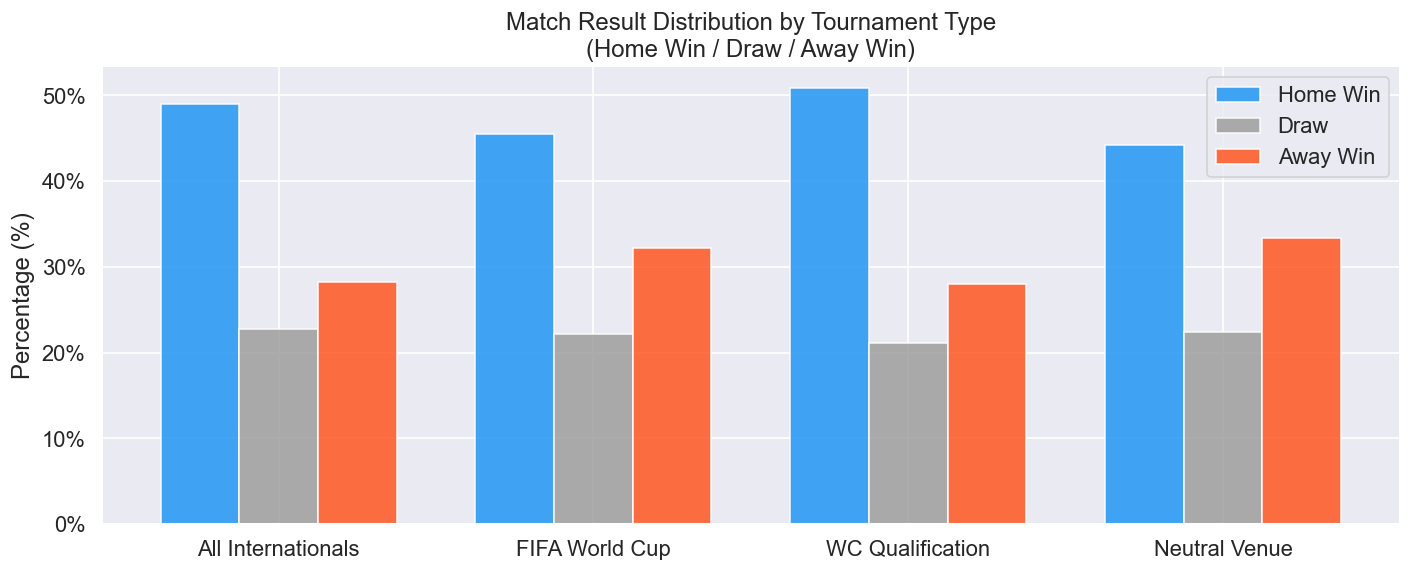

In [10]:
# Filtros relevantes
tournament_filters = {
    "All Internationals": df_results,
    "FIFA World Cup": df_results[df_results["tournament"] == "FIFA World Cup"],
    "WC Qualification": df_results[df_results["tournament"] == "FIFA World Cup qualification"],
    "Neutral Venue": df_results[df_results["neutral"] == True],
}

fig, ax = plt.subplots(figsize=(12, 5))

categories = ["Home Win", "Draw", "Away Win"]
colors = ["#2196F3", "#9E9E9E", "#FF5722"]
x = np.arange(len(tournament_filters))
width = 0.25

for i, cat in enumerate(categories):
    vals = []
    for label, df_f in tournament_filters.items():
        df_tmp = df_f.copy()
        df_tmp["result"] = df_tmp.apply(
            lambda r: "Home Win" if r.home_score > r.away_score
            else ("Away Win" if r.home_score < r.away_score else "Draw"),
            axis=1
        )
        vals.append(df_tmp["result"].value_counts(normalize=True).get(cat, 0) * 100)
    ax.bar(x + i * width, vals, width, label=cat, color=colors[i], alpha=0.85, edgecolor="white")

ax.set_xticks(x + width)
ax.set_xticklabels(list(tournament_filters.keys()))
ax.set_ylabel("Percentage (%)")
ax.set_title("Match Result Distribution by Tournament Type\n(Home Win / Draw / Away Win)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_result_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3 Historical goals trend — How has football evolved since 1872?

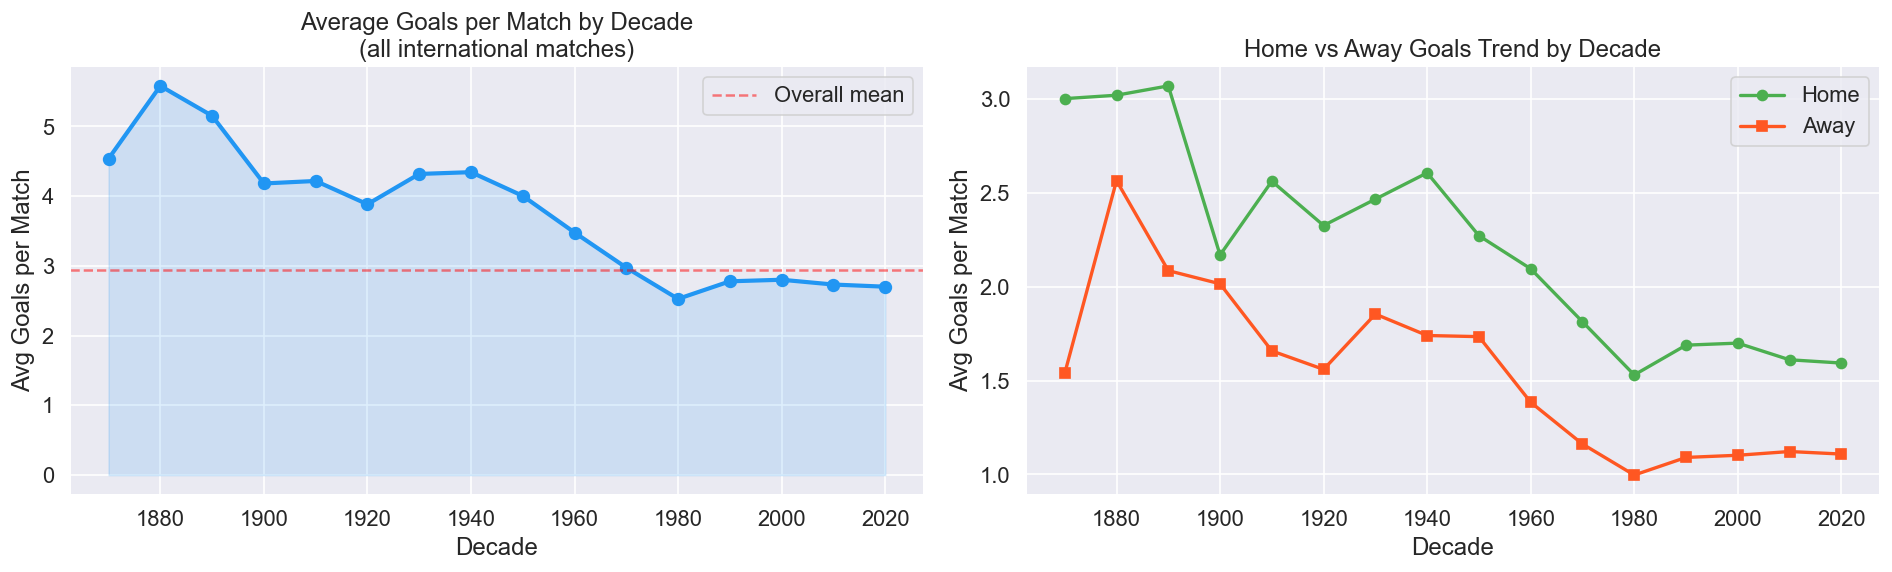

Goals trend by decade:
 decade  matches  avg_goals  avg_home  avg_away
   1950     1651      4.004     2.271     1.733
   1960     2971      3.479     2.095     1.384
   1970     4133      2.975     1.813     1.162
   1980     5025      2.527     1.530     0.997
   1990     6944      2.779     1.688     1.091
   2000     9525      2.801     1.699     1.102
   2010     9756      2.733     1.610     1.122
   2020     5732      2.702     1.593     1.109


In [11]:
# Goals per match by decade
df_results["year"] = df_results["date"].dt.year
df_results["decade"] = (df_results["year"] // 10) * 10

decade_stats = (
    df_results.groupby("decade")
    .agg(
        matches=("total_goals", "count"),
        avg_goals=("total_goals", "mean"),
        avg_home=("home_score", "mean"),
        avg_away=("away_score", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Avg goals per decade ---
axes[0].plot(
    decade_stats["decade"],
    decade_stats["avg_goals"],
    marker="o", linewidth=2.5, color="#2196F3", markersize=7
)
axes[0].fill_between(decade_stats["decade"], decade_stats["avg_goals"], alpha=0.15, color="#2196F3")
axes[0].set_title("Average Goals per Match by Decade\n(all international matches)")
axes[0].set_xlabel("Decade")
axes[0].set_ylabel("Avg Goals per Match")
axes[0].axhline(df_results["total_goals"].mean(), color="red", linestyle="--", alpha=0.5, label="Overall mean")
axes[0].legend()

# --- Home vs Away trend ---
axes[1].plot(decade_stats["decade"], decade_stats["avg_home"], marker="o", label="Home", color="#4CAF50", linewidth=2)
axes[1].plot(decade_stats["decade"], decade_stats["avg_away"], marker="s", label="Away", color="#FF5722", linewidth=2)
axes[1].set_title("Home vs Away Goals Trend by Decade")
axes[1].set_xlabel("Decade")
axes[1].set_ylabel("Avg Goals per Match")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_goals_trend_by_decade.png", dpi=150, bbox_inches="tight")
plt.show()

print("Goals trend by decade:")
print(decade_stats.tail(8).to_string(index=False))

### 2.4 FIFA Rankings distribution — Current WC2026 qualified teams

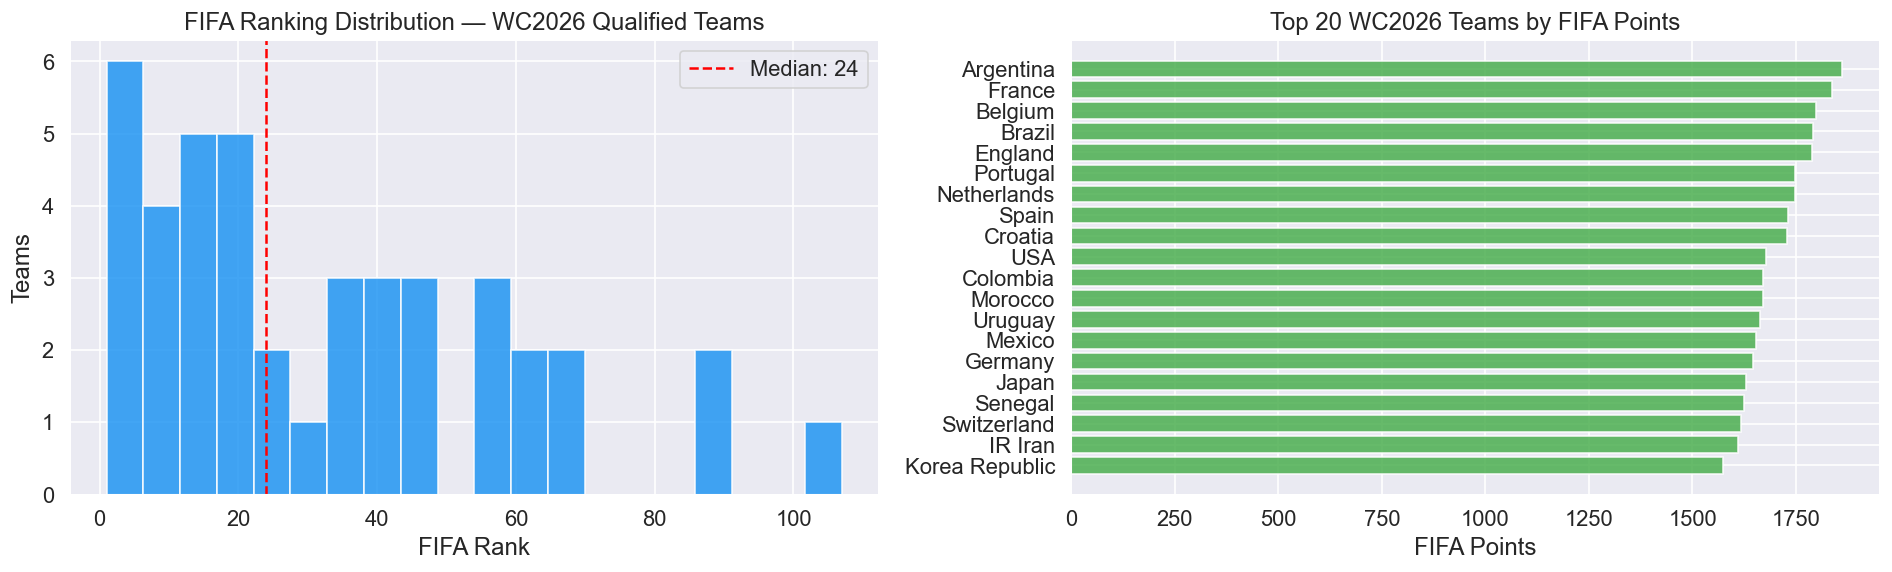

Top 10 WC2026 teams by FIFA ranking:
country_full   rank  total_points
   Argentina  1.000      1860.140
      France  2.000      1837.470
     Belgium  3.000      1797.980
      Brazil  4.000      1791.850
     England  5.000      1787.880
    Portugal  6.000      1747.040
 Netherlands  7.000      1746.660
       Spain  8.000      1729.920
     Croatia  9.000      1728.300
         USA 11.000      1676.520


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Rank distribution ---
axes[0].hist(df_rank_wc["rank"], bins=20, color="#2196F3", edgecolor="white", alpha=0.85)
axes[0].set_title("FIFA Ranking Distribution — WC2026 Qualified Teams")
axes[0].set_xlabel("FIFA Rank")
axes[0].set_ylabel("Teams")
axes[0].axvline(
    df_rank_wc["rank"].median(), color="red", linestyle="--",
    label=f"Median: {df_rank_wc['rank'].median():.0f}"
)
axes[0].legend()

# --- Top 20 by points ---
df_top20 = df_rank_wc.nsmallest(20, "rank").sort_values("rank")
axes[1].barh(df_top20["country_full"], df_top20["total_points"], color="#4CAF50", alpha=0.85, edgecolor="white")
axes[1].invert_yaxis()
axes[1].set_title("Top 20 WC2026 Teams by FIFA Points")
axes[1].set_xlabel("FIFA Points")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_rankings_wc2026.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 WC2026 teams by FIFA ranking:")
print(df_top20[["country_full", "rank", "total_points"]].head(10).to_string(index=False))